In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv(r"C:\Users\deepj\Documents\customer-profitability-analysis\data\processed\retail_cleaned.csv")
print(df.shape)
df.head()

(397884, 13)


,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue,year,month,year_month
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,2010-12
1,1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,2010-12
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12


In [3]:
customer = df.groupby("CustomerID")["revenue"].sum().reset_index()
customer.columns = ["CustomerID", "total_revenue"]
customer = customer.sort_values("total_revenue", ascending=False).reset_index(drop=True)
customer.head(10)

,CustomerID,total_revenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194550.79
3,16446.0,168472.50
4,14911.0,143825.06
5,12415.0,124914.53
6,14156.0,117379.63
7,17511.0,91062.38
8,16029.0,81024.84
9,12346.0,77183.60


In [5]:
customer["cumulative_revenue"] = customer["total_revenue"].cumsum()
customer["cumulative_pct"] = (customer["cumulative_revenue"] / customer["total_revenue"].sum() * 100).round(2)
customer["customer_pct"] = ((customer.index + 1) / len(customer) * 100).round(2)
customer.head()

,CustomerID,total_revenue,cumulative_revenue,cumulative_pct,customer_pct
0,14646.0,280206.02,280206.02,3.14,0.02
1,18102.0,259657.30,539863.32,6.06,0.05
2,17450.0,194550.79,734414.11,8.24,0.07
3,16446.0,168472.50,902886.61,10.13,0.09
4,14911.0,143825.06,1046711.67,11.75,0.12


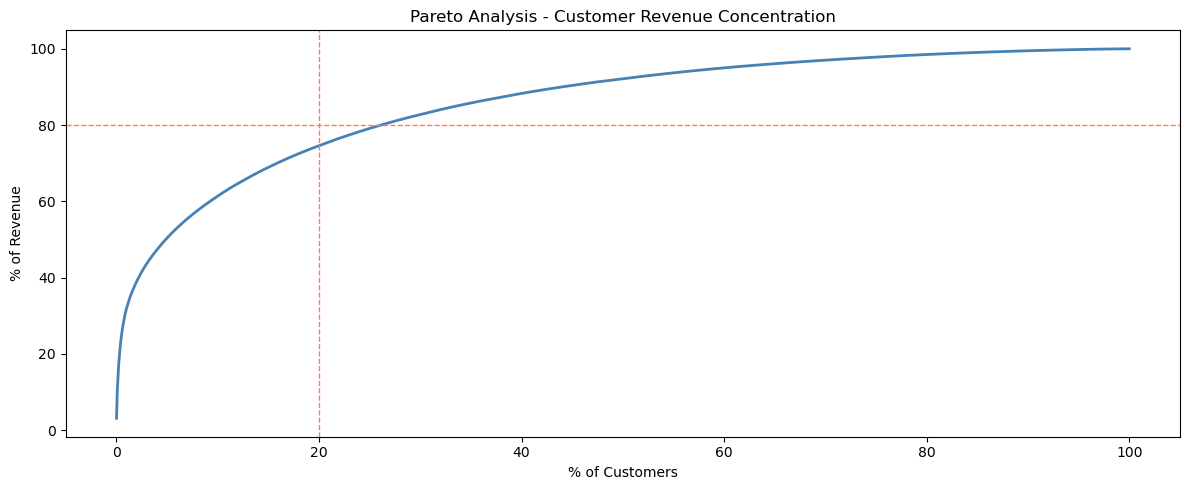

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(customer["customer_pct"], customer["cumulative_pct"], color="steelblue", linewidth=2)
ax.axhline(y=80, color="coral", linestyle="--", linewidth=1)
ax.axvline(x=20, color="coral", linestyle="--", linewidth=1)
ax.set(title="Pareto Analysis - Customer Revenue Concentration", xlabel="% of Customers", ylabel="% of Revenue")
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\customer-profitability-analysis\reports\pareto_analysis.png")
plt.show()

In [7]:
customer["segment"] = customer["customer_pct"].apply(lambda x: "High Value" if x <= 20 else ("Mid Value" if x <= 50 else "Low Value"))
customer["segment"].value_counts()

segment
Low Value     2169
Mid Value     1302
High Value     867
Name: count, dtype: int64

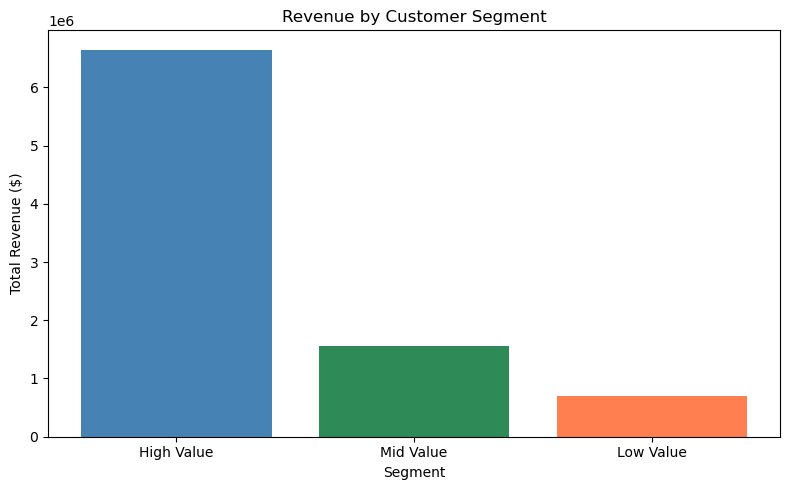

In [8]:
segment_revenue = customer.groupby("segment")["total_revenue"].sum().reset_index()
segment_revenue = segment_revenue.sort_values("total_revenue", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(segment_revenue["segment"], segment_revenue["total_revenue"], color=["steelblue", "seagreen", "coral"])
ax.set(title="Revenue by Customer Segment", xlabel="Segment", ylabel="Total Revenue ($)")
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\customer-profitability-analysis\reports\revenue_by_segment.png")
plt.show()

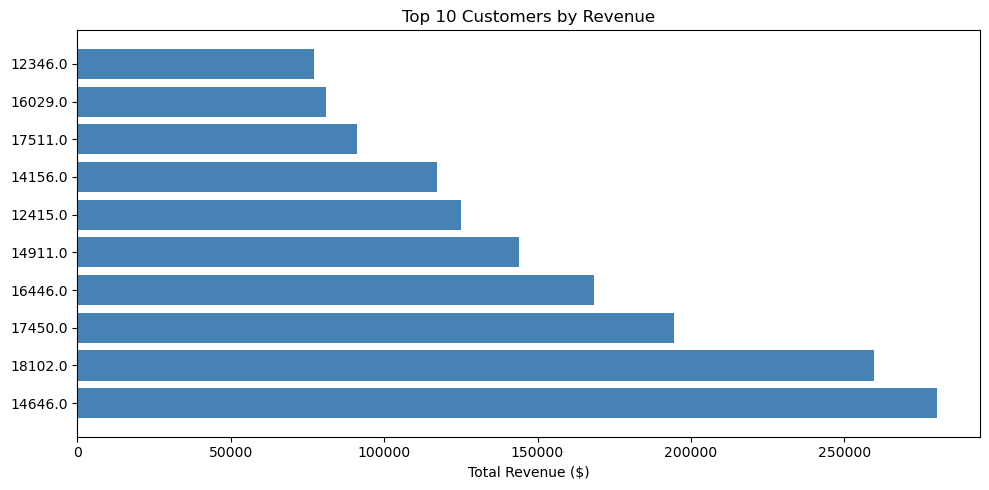

In [9]:
top10 = customer.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10["CustomerID"].astype(str), top10["total_revenue"], color="steelblue")
ax.set(title="Top 10 Customers by Revenue", xlabel="Total Revenue ($)")
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\customer-profitability-analysis\reports\top10_customers.png")
plt.show()

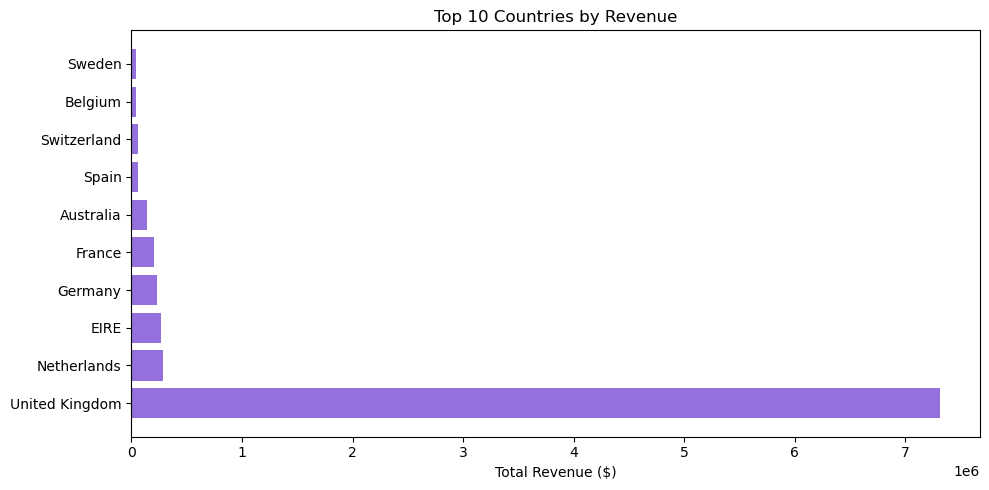

In [10]:
country = df.groupby("Country")["revenue"].sum().reset_index()
country = country.sort_values("revenue", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(country["Country"], country["revenue"], color="mediumpurple")
ax.set(title="Top 10 Countries by Revenue", xlabel="Total Revenue ($)")
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\customer-profitability-analysis\reports\revenue_by_country.png")
plt.show()

In [11]:
customer.to_csv(r"C:\Users\deepj\Documents\customer-profitability-analysis\data\processed\customer_segments.csv", index=False)
print("saved!")

saved!


In [12]:
total_revenue = df["revenue"].sum()
total_customers = customer["CustomerID"].nunique()
top_20_pct = customer[customer["customer_pct"] <= 20]["total_revenue"].sum()
top_20_contribution = round((top_20_pct / total_revenue * 100), 2)
top_customer = customer.iloc[0]["CustomerID"]
top_customer_revenue = customer.iloc[0]["total_revenue"]
top_country = df.groupby("Country")["revenue"].sum().idxmax()
high_value = (customer["segment"] == "High Value").sum()
mid_value = (customer["segment"] == "Mid Value").sum()
low_value = (customer["segment"] == "Low Value").sum()
avg_order = df.groupby("InvoiceNo")["revenue"].sum().mean()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Customers: {total_customers}")
print(f"Top 20% Customer Revenue Contribution: {top_20_contribution}%")
print(f"Top Customer ID: {top_customer} (${top_customer_revenue:,.2f})")
print(f"Top Country: {top_country}")
print(f"High Value Customers: {high_value}")
print(f"Mid Value Customers: {mid_value}")
print(f"Low Value Customers: {low_value}")
print(f"Average Order Value: ${avg_order:,.2f}")

Total Revenue: $8,911,407.90
Total Customers: 4338
Top 20% Customer Revenue Contribution: 74.59%
Top Customer ID: 14646.0 ($280,206.02)
Top Country: United Kingdom
High Value Customers: 867
Mid Value Customers: 1302
Low Value Customers: 2169
Average Order Value: $480.87
